# Example: Assessment to selection

In [3]:
from pathlib import Path

from stocksift.selection_policy_long import (
    LongEqualFeatureScore,
    LongEqualGroupScore,
    LongFeatureScore,
    LongGroupScore,
    LongThresholdFilter,
)
from stocksift.stock_assessment import StockAssessment

In [9]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [10]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(DATA_DIR)
prices, ratios = assessment.load_inputs(PRICE_CSV, RATIO_CSV)
features = assessment.assess(prices, ratios)
print(f"Assessment universe: {len(features)}")

Assessment universe: 200


In [6]:
# 2. Threshold eligibility example. Passing rows have no priority ranking.
threshold = LongThresholdFilter(
    rules=[
        ("per_hist_pct", "<=", 90),
        ("eps_growth_pct", ">=", 20),
        ("momentum_12m_pct", ">=", 20),
    ]
)
eligible = threshold.select(features)
print(f"Threshold eligible: {len(eligible)}")
print(threshold.trace(features).to_string(index=False))

Threshold eligible: 105
 step          feature operator threshold  remaining
    0 initial_universe               <NA>        200
    1     per_hist_pct       <=      90.0        163
    2   eps_growth_pct       >=      20.0        127
    3 momentum_12m_pct       >=      20.0        105


In [10]:
# 3. Equal-feature ranking. LongEqualFeatureScore explicitly assigns weight
#    1.0 to every feature, independent of LongFeatureScore defaults.
equal_feature = LongEqualFeatureScore(
    top_n=20,
)
feature_ranked = equal_feature.select(features)
feature_ranked

,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_6m,momentum_12m,momentum_6m_pct,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,selection_score,selection_rank
0,483650,2026-08-13,236000.0,16022,35.79,14.73,6594,1.11,2629,36.360,...,0.358664,0.385790,90.0,65.829146,0.801362,-0.350134,67.5,27.0,86.167663,1
1,007660,2026-08-13,96800.0,10292,42.49,9.41,2278,0.24,230,37.420,...,-0.047244,0.538951,64.0,75.376884,1.212491,-0.633209,94.5,92.0,85.644984,2
2,002380,2026-08-13,456000.0,1063952,2.18,0.43,209201,3.29,15000,2.010,...,-0.190053,0.209549,34.5,54.773869,0.754050,-0.481618,63.0,62.0,81.769943,3
3,329180,2026-08-13,496000.0,89025,31.59,5.57,15702,1.14,5661,30.870,...,-0.086556,0.062099,58.5,45.226131,0.660479,-0.417450,50.0,45.5,81.419749,4
4,062040,2026-08-13,188000.0,19269,38.36,9.76,4901,0.66,1250,33.790,...,0.292096,0.636205,87.5,79.899497,1.045281,-0.637781,87.0,93.5,79.458413,5
5,192820,2026-08-13,249000.0,49196,22.96,5.06,10847,1.33,3300,17.120,...,0.226601,0.300940,86.5,58.793970,0.629403,-0.404928,43.5,40.5,78.793027,6
6,064350,2026-08-13,147600.0,28211,20.92,5.23,7055,0.41,600,20.795,...,-0.267494,-0.184981,19.5,15.577889,0.899932,-0.553532,77.5,77.5,76.892334,7
7,017960,2026-08-13,24300.0,11519,11.89,2.11,2043,1.32,320,11.160,...,-0.303725,-0.214863,14.0,12.060302,0.679848,-0.630268,53.0,90.5,75.927219,8
8,003230,2026-08-13,1219000.0,166650,23.37,7.31,52156,0.39,4800,23.140,...,0.024370,-0.135461,70.5,21.105528,0.545059,-0.373006,31.0,32.5,75.450203,9
9,009540,2026-08-13,371500.0,187883,12.12,1.98,30664,3.31,12300,12.165,...,-0.065409,-0.021080,62.5,33.668342,0.652046,-0.318040,46.5,19.0,75.061744,10


In [11]:
# 4. Equal-group ranking. Feature weights within each group and group weights
#    are both explicitly 1.0 inside LongEqualGroupScore.
equal_group = LongEqualGroupScore(
    top_n=20,
)
group_ranked = equal_group.select(features)
group_ranked

,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,483650,2026-08-13,236000.0,16022,35.79,14.73,6594,1.11,2629,36.360,...,65.829146,0.801362,-0.350134,67.5,27.0,81.652261,97.690259,77.914573,85.752364,1
1,007660,2026-08-13,96800.0,10292,42.49,9.41,2278,0.24,230,37.420,...,75.376884,1.212491,-0.633209,94.5,92.0,90.870295,89.315596,69.688442,83.291444,2
2,062040,2026-08-13,188000.0,19269,38.36,9.76,4901,0.66,1250,33.790,...,79.899497,1.045281,-0.637781,87.0,93.5,70.939617,87.989251,83.699749,80.876206,3
3,192820,2026-08-13,249000.0,49196,22.96,5.06,10847,1.33,3300,17.120,...,58.793970,0.629403,-0.404928,43.5,40.5,82.047419,78.551199,72.646985,77.748534,4
4,329180,2026-08-13,496000.0,89025,31.59,5.57,15702,1.14,5661,30.870,...,45.226131,0.660479,-0.417450,50.0,45.5,88.507622,91.673706,51.863065,77.348131,5
5,298040,2026-08-13,3017000.0,252555,54.04,11.95,55832,0.25,7500,48.000,...,93.467337,1.103024,-0.588350,91.0,83.5,54.501213,85.170852,90.233668,76.635245,6
6,002380,2026-08-13,456000.0,1063952,2.18,0.43,209201,3.29,15000,2.010,...,54.773869,0.754050,-0.481618,63.0,62.0,92.813616,91.800385,44.636935,76.416979,7
7,066570,2026-08-13,206500.0,132659,38.74,1.56,5330,0.65,1350,32.685,...,94.974874,1.424853,-0.622930,99.0,90.0,49.218263,80.177122,95.487437,74.960941,8
8,375500,2026-08-13,73500.0,126050,8.40,0.58,8746,1.21,890,7.270,...,84.422111,0.876991,-0.488780,75.0,66.0,55.301461,78.211986,88.961055,74.158168,9
9,009540,2026-08-13,371500.0,187883,12.12,1.98,30664,3.31,12300,12.165,...,33.668342,0.652046,-0.318040,46.5,19.0,80.351681,85.993543,48.084171,71.476465,10


In [12]:
# 5. Compose policies while continuing to use the same canonical feature table.
eligible_group_ranked = equal_group.select(
    features,
    tickers=eligible["ticker"],
)
print("\nEqual-group top 20 within threshold-eligible tickers")

eligible_group_ranked


Equal-group top 20 within threshold-eligible tickers


,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,483650,2026-08-13,236000.0,16022,35.79,14.73,6594,1.11,2629,36.360,...,65.829146,0.801362,-0.350134,67.5,27.0,81.652261,97.690259,77.914573,85.752364,1
1,007660,2026-08-13,96800.0,10292,42.49,9.41,2278,0.24,230,37.420,...,75.376884,1.212491,-0.633209,94.5,92.0,90.870295,89.315596,69.688442,83.291444,2
2,062040,2026-08-13,188000.0,19269,38.36,9.76,4901,0.66,1250,33.790,...,79.899497,1.045281,-0.637781,87.0,93.5,70.939617,87.989251,83.699749,80.876206,3
3,192820,2026-08-13,249000.0,49196,22.96,5.06,10847,1.33,3300,17.120,...,58.793970,0.629403,-0.404928,43.5,40.5,82.047419,78.551199,72.646985,77.748534,4
4,329180,2026-08-13,496000.0,89025,31.59,5.57,15702,1.14,5661,30.870,...,45.226131,0.660479,-0.417450,50.0,45.5,88.507622,91.673706,51.863065,77.348131,5
5,298040,2026-08-13,3017000.0,252555,54.04,11.95,55832,0.25,7500,48.000,...,93.467337,1.103024,-0.588350,91.0,83.5,54.501213,85.170852,90.233668,76.635245,6
6,002380,2026-08-13,456000.0,1063952,2.18,0.43,209201,3.29,15000,2.010,...,54.773869,0.754050,-0.481618,63.0,62.0,92.813616,91.800385,44.636935,76.416979,7
7,066570,2026-08-13,206500.0,132659,38.74,1.56,5330,0.65,1350,32.685,...,94.974874,1.424853,-0.622930,99.0,90.0,49.218263,80.177122,95.487437,74.960941,8
8,375500,2026-08-13,73500.0,126050,8.40,0.58,8746,1.21,890,7.270,...,84.422111,0.876991,-0.488780,75.0,66.0,55.301461,78.211986,88.961055,74.158168,9
9,009540,2026-08-13,371500.0,187883,12.12,1.98,30664,3.31,12300,12.165,...,33.668342,0.652046,-0.318040,46.5,19.0,80.351681,85.993543,48.084171,71.476465,10


# Recipes

In [10]:
from stock_assessment import StockAssessment
from selection_recipes_long import (
    apply_selection,
    evaluate_recipe,
    evaluate_selected_forward_returns,
    plot_forward_returns,
    compare_selection_to_universe,
    plot_forward_return_distribution
)

In [11]:
BASE_DIR = '../data/'
CONFIG = "stock_assessment.yaml"
PRICE_CSV = BASE_DIR + "kospi200_prices_260814.csv"
RATIO_CSV = BASE_DIR + "kospi200_ratios_260814.csv"

In [12]:
assessment = StockAssessment(CONFIG)
prices, ratios = assessment.load_inputs(PRICE_CSV, RATIO_CSV)

In [16]:
date = '2025-09-01'
#date = None

# Current selection
features = assessment.assess(
    prices,
    ratios,
    as_of = date
)

In [5]:
selected = apply_selection(features)

<Axes: title={'center': 'Forward Returns by Selected Stock'}, xlabel='Forward horizon', ylabel='Return'>

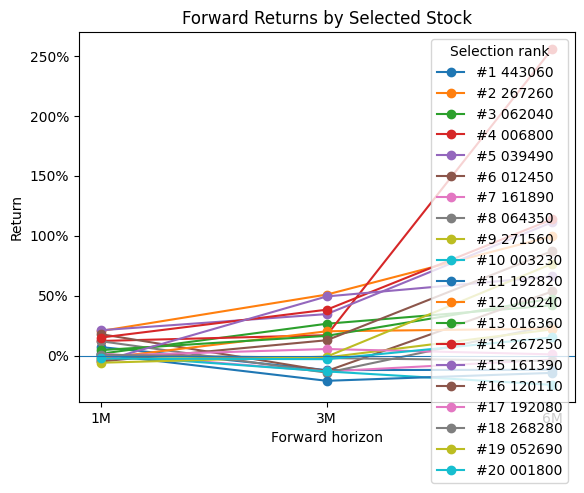

In [7]:
# Evaluate the already-produced selection
evaluated = evaluate_selected_forward_returns(
    selected,
    prices,
    price_date_col=assessment.price_cols["date"],
)

plot_forward_returns(evaluated)

In [8]:
details, distribution, summary = compare_selection_to_universe(
    selected,
    features,
    prices,
)

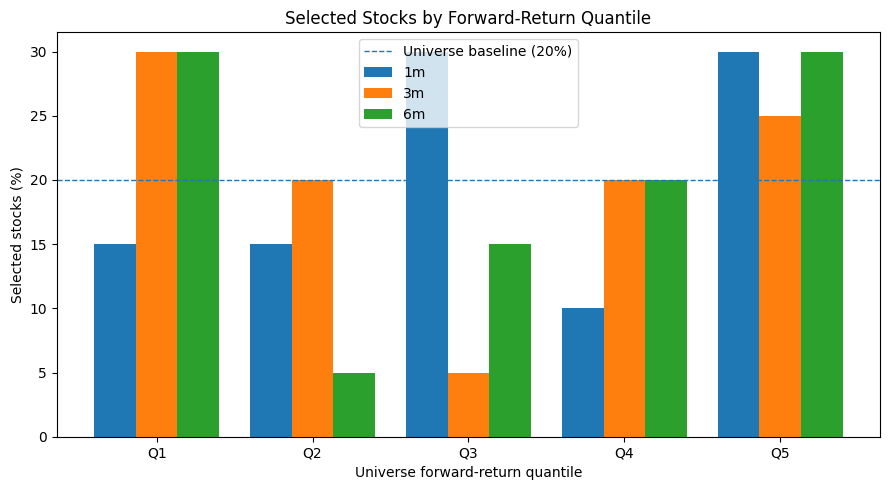

In [9]:
details
distribution
summary

_ = plot_forward_return_distribution(
    distribution
)

In [12]:
from selection_policy_long import LongThresholdFilter, LongEqualGroupScore


CORE_LONG_THRESHOLD_RULES = (
    ("per_hist_pct", "<=", 50.0),
    ("eps_growth_pct", ">=", 50.0),
    ("momentum_12m_pct", ">=", 50.0),
)

policies = [
    LongThresholdFilter(rules=CORE_LONG_THRESHOLD_RULES),
    LongEqualGroupScore(top_n=5),
]

<Axes: title={'center': 'Forward Returns by Selected Stock'}, xlabel='Forward horizon', ylabel='Return'>

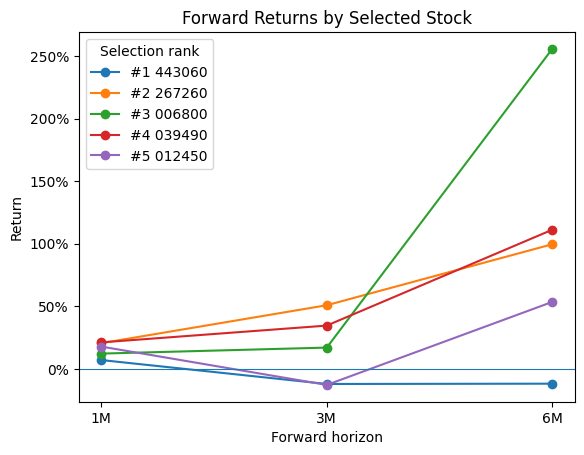

In [37]:
# Historical point-in-time evaluation:
# regenerate features as of the date -> apply recipe -> forward returns
evaluated = evaluate_recipe(
    assessment,
    prices,
    ratios,
    as_of=date,
    horizons=(1, 3, 6),
    policies=policies
)

plot_forward_returns(evaluated)

In [38]:
details, distribution, summary = compare_selection_to_universe(
    evaluated,
    features,
    prices,
    horizons = (1, 3, 6)
)

In [39]:
distribution

,horizon,quantile,selected_count,selected_proportion,baseline_proportion
0,1m,Q1,0,0.0,0.2
1,1m,Q2,0,0.0,0.2
2,1m,Q3,0,0.0,0.2
3,1m,Q4,1,0.2,0.2
4,1m,Q5,4,0.8,0.2
5,3m,Q1,2,0.4,0.2
6,3m,Q2,0,0.0,0.2
7,3m,Q3,0,0.0,0.2
8,3m,Q4,1,0.2,0.2
9,3m,Q5,2,0.4,0.2


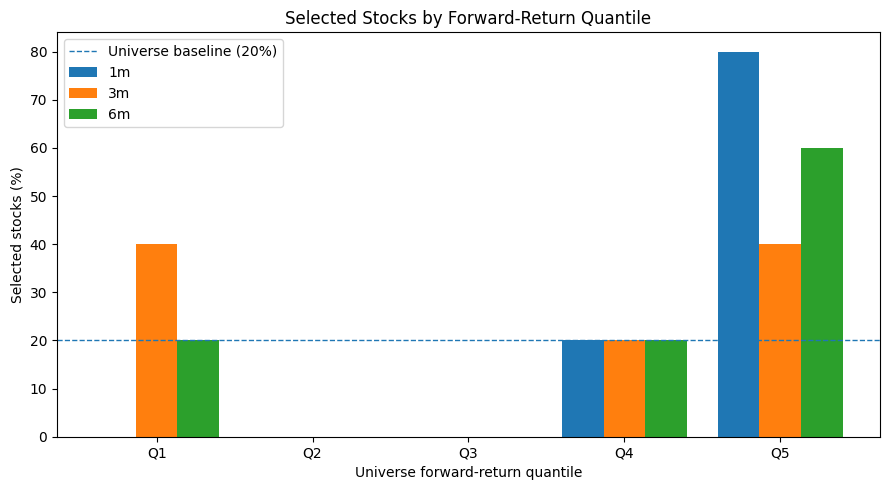

In [42]:
_ = plot_forward_return_distribution(
    distribution
)